In [5]:
from matplotlib import pyplot as plt
import numpy as np
import os

In [6]:
fs = 10e6
fc = 2e6 #中心频率
threshold = 120
MODES_PREAMBLE_US = 8
MODES_LONG_MSG_BITS = 112

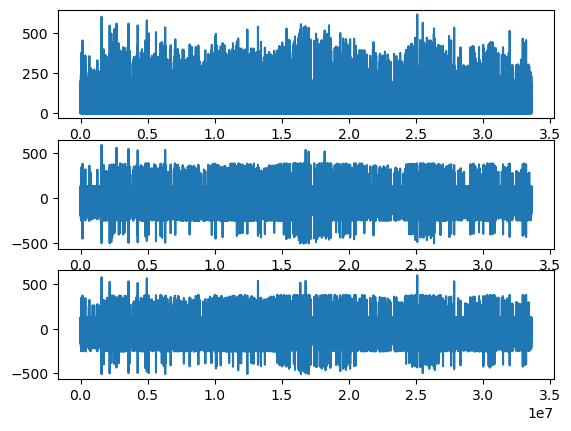

In [7]:
# u = np.fromfile('u.dat', dtype=np.byte)
I = np.loadtxt('I.dat')
Q = np.loadtxt('Q.dat')
signal = I+1j*Q
plt.figure()
plt.subplot(311)
plt.plot(np.abs(signal))
plt.subplot(312)
plt.plot(np.real(signal))
plt.subplot(313)
plt.plot(np.imag(signal))
plt.show()

In [8]:
import pyModeS as pms
import bin_str2hex as bsh
pp = np.abs(signal)
mark = []
mean_ = np.zeros((1,240))
msg = [0]*112
for i in np.arange(0,int((pp.shape[0]-fs*120e-6-1))):
    uu = pp[i:int(i+120e-6*fs-1)]
    it = int(0.5e-6*fs)
    if max(uu)<150:
        continue
    for j in np.arange(0,240):
        mean_[0,j]=np.mean(uu[j*it+1:(j+1)*it])
    
    if mean_[0,0]>mean_[0,1] and \
        mean_[0,1] < mean_[0,2] and \
        mean_[0,2] > mean_[0,3] and \
        mean_[0,2] > mean_[0,6] and \
        mean_[0,3] < mean_[0,0] and \
        mean_[0,4] < mean_[0,7] and \
        mean_[0,3] < mean_[0,7] and \
        mean_[0,4] < mean_[0,0] and \
        mean_[0,5] < mean_[0,0] and \
        mean_[0,6] < mean_[0,0] and \
        mean_[0,7] > mean_[0,8] and \
        mean_[0,8] < mean_[0,9] and \
        mean_[0,9] > mean_[0,5] and \
        mean_[0,9] > mean_[0,6] and \
        pp[i] > pp[i+it] and \
        pp[i+it-1] > pp[i+it] and \
        pp[i+it*3-1] > pp[i+it*3]:
        if  mean_[0,0]< threshold:
            continue

        # plt.subplot(211)        
        
        #%%%%开始转码%%%%
        for j in np.arange(0,224,2):
            low = mean_[0,j+MODES_PREAMBLE_US*2]
            high = mean_[0,MODES_PREAMBLE_US*2+1+j]
            delta = low - high
            
            if low>high:
                msg[int(j/2)]='1'
            else:
                msg[int(j/2)]='0'

        digital_msg = bsh.bin_str_matrix_to_hex(msg)
        if pms.df(digital_msg)!=17:
            continue
        if pms.crc(digital_msg) !=0:  # CRC fail
                continue
        # plt.subplot(311)        
        # plt.plot(pp[i:i+1200-1])
        # plt.subplot(312)
        # plt.plot(I[i:i+1200-1])
        # plt.subplot(313)
        # plt.plot(Q[i:i+1200-1])
        # plt.show()
        # plt.savefig('p.png')
        print('good_preamble')
        a = open('u.csv','a',newline='')
        import csv
        aa = csv.writer(a)
        p = [str(y) for y in np.array(I[i:i+1200-1]+1j*Q[i:i+1200-1])]
        tmp = ''.join(msg)
        p.append(tmp)
        
        p.append(digital_msg)
        aa.writerow(p)
        # aa.writerow(p)
        a.close()
        print(digital_msg)
        i = i+120e-6*fs

good_preamble
8D789249EA2D0858011C084942F1
good_preamble
8D78059099887BAF70482DFF4F87
good_preamble
8D750420EA469866211C08BA5250
good_preamble
8D781B39990D33A370045A0A7CA0
good_preamble
8D78059099887BAF904C2DE2F951
good_preamble
8D780ADE581BF30614CAF0DB2060
good_preamble
8D781B39230C22B5D72E2086386E
good_preamble
8D750420EA469866211C08BA5250
good_preamble
8D750420EA469866211C08BA5250
good_preamble
8D780ADE581D36C596291772A1E9
good_preamble
8D780590585F331A10A000266B7F
good_preamble
8D750420990C17B878085EE0E686
good_preamble
8D780ADE9908709B10B4094BD676
good_preamble
8D780ADE581DA30506CB34A7AC06
good_preamble
8D780590585F66D88DFF02D775E6
good_preamble
8D78059099087CAFD0602D86EC1F
